# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [3]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [4]:
# Inspect the shapes of the datasets
# X_train and X_test
print("Data inspection for X and Y Train-Test sample\n")
print("Training Set: X and y: ")
print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("\nTesting Set: X and y: ")
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
print(f'\nBefore one-hot encoding: {y_train[0]}')
y_train_onehot_enc = to_categorical(y_train, num_classes=10)
y_test_onehot_enc = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train_onehot_enc[0]}')


Data inspection for X and Y Train-Test sample

Training Set: X and y: 
X_train:  (60000, 28, 28)
y_train:  (60000,)

Testing Set: X and y: 
X_test:  (10000, 28, 28)
y_test:  (10000,)

Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


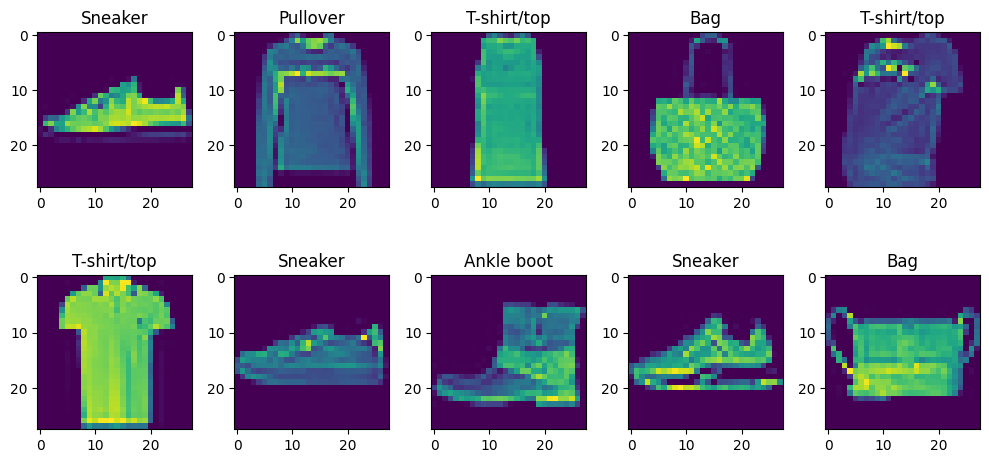

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected
# Displaying random 10 grayscale images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

for i in range(10):
    # Showing different image in each run
    rand_img = np.random.randint(0, len(X_train))
    axes[i].imshow(X_train[rand_img])
    axes[i].set_title(f"{class_names[y_train[rand_img]]}")

plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The data looks good as expected from the Fashion MNIST dataset. The images are low resolution grayscale images and seems to be clearly visible for each separate categories.
No issues seems to be in the dataset however low resolution images across categories look very similar like Coat and Pullover categories have similar images. Same with Shirt and coat categories.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model

In [5]:
# Input layer
model.add(Flatten(input_shape=(28,28)))  # Input tensor specifying the shape

# Output layer
model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the model using `model.compile()`

model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer ='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

In [7]:
# Train the model with `model.fit()`

history = model.fit(
    X_train, # Training data
    y_train_onehot_enc, # Training labels OneHot Encoded
    epochs=15, # Number of epochs
    batch_size=64, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5773 - loss: 1.3451 - val_accuracy: 0.7559 - val_loss: 0.7613
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7671 - loss: 0.7312 - val_accuracy: 0.7893 - val_loss: 0.6565
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7914 - loss: 0.6509 - val_accuracy: 0.8012 - val_loss: 0.6112
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8035 - loss: 0.6063 - val_accuracy: 0.8105 - val_loss: 0.5788
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8126 - loss: 0.5751 - val_accuracy: 0.8158 - val_loss: 0.5586
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8188 - loss: 0.5563 - val_accuracy: 0.8179 - val_loss: 0.5438
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8211 - loss: 0.5387 - val_accuracy: 0.8217 - val_loss: 0.5311
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8294 - loss: 0.5243 - val_accuracy: 0.

With 15 Epochs shows validation loss has decreased and there is an increase in accuracy indicating model is learning.

Evaluating model on the Test set

In [8]:
# Evaluate the model with `model.evaluate()`

loss, accuracy = model.evaluate(X_test, y_test_onehot_enc)
print(
    f'Loss: {loss:4f}',
    f'\nAccuracy: {accuracy*100:4f}%'
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8309 - loss: 0.5003
Loss: 0.509862 
Accuracy: 82.590002%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The baseline model has a 82.7% accuracy with a loss of 0.49. It validates model is able to learn separate categories and able to classify well on the test set.
The performance is quite good as we can see in the below Loss and Accuracy metrics indicating model is able to learn meaningful pattern and classify images into different categories

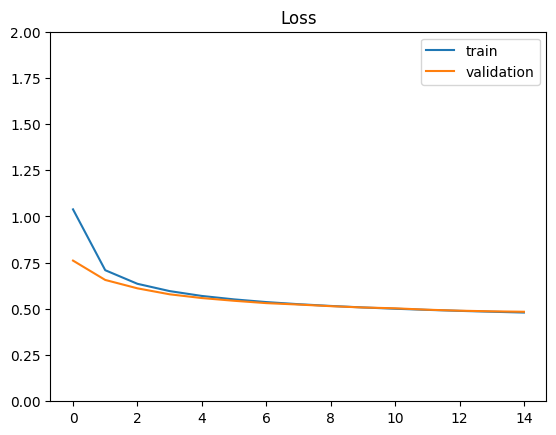

In [9]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss');


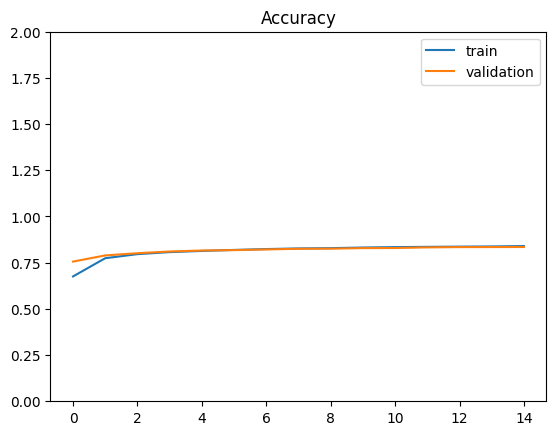

In [10]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Accuracy');

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [11]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()



In [12]:
# Create a simple CNN model
from keras.layers import MaxPooling2D,Flatten,Dense

# First layer
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second layer
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten layer no parameters
model.add(Flatten())

# Fully-Connected layers
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,482 (240.16 KB)

 Trainable params: 61,482 (240.16 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile the model

model.compile(
    loss='categorical_crossentropy',# Loss function
    optimizer='adam',               # Optimizer
    metrics=['accuracy']            # Metrics to evaluate the model
)

In [14]:
# Train the model

history_cnn = model.fit(
    X_train, # Training data
    y_train_onehot_enc, # Training labels OneHot Encoded
    epochs=10, # Number of epochs
    batch_size=64, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 0.7131 - loss: 0.8190 - val_accuracy: 0.8520 - val_loss: 0.4170
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 102ms/step - accuracy: 0.8586 - loss: 0.3885 - val_accuracy: 0.8672 - val_loss: 0.3667
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step - accuracy: 0.8770 - loss: 0.3376 - val_accuracy: 0.8830 - val_loss: 0.3306
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.8893 - loss: 0.2992 - val_accuracy: 0.8873 - val_loss: 0.3156
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.9010 - loss: 0.2726 - val_accuracy: 0.8902 - val_loss: 0.3111
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9037 - loss: 0.2602 - val_accuracy: 0.8992 - val_loss: 0.2820
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.9132 - loss: 0.2368 - val_accuracy: 0.8944 - val_loss: 0.2895
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.9191 - loss: 0.2224 

In [15]:
# Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test_onehot_enc)
print(
    f'Loss: {loss:4f}',
    f'\nAccuracy: {accuracy*100:4f}%'
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9001 - loss: 0.2990
Loss: 0.280346 
Accuracy: 90.009999%


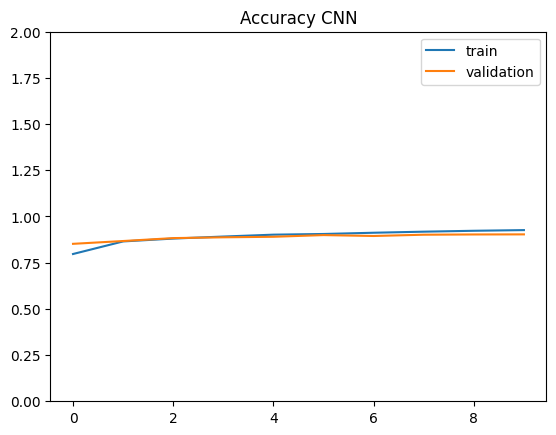

In [22]:
plt.plot(history_cnn.history['accuracy'], label='train')
plt.plot(history_cnn.history['val_accuracy'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Accuracy CNN');

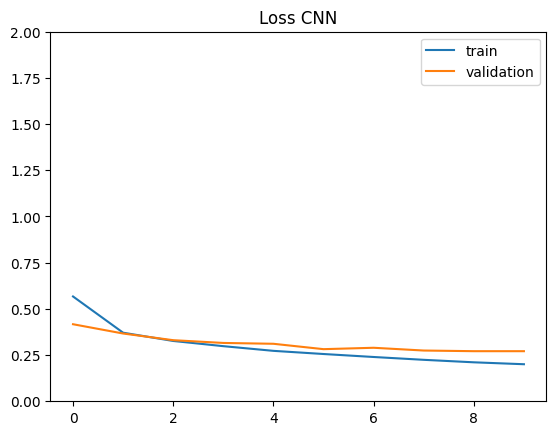

In [23]:
plt.plot(history_cnn.history['loss'], label='train')
plt.plot(history_cnn.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss CNN');

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

Yes, the CNN performed better than the baseline model achieving high accuracy. While, baseline model achieved 82.7% accuracy with same batch size and epochs, the CNN achieved accuracy of 90.48%  on evaluation.
The model leveraged multiple convolutional and pooling layers to extract features and reduce dimensionality.

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [16]:
import tensorflow  as tf 


In [64]:
# A. Test Hyperparameters
No_of_filters = [32,64,128]

Exp_History = {}

for i in No_of_filters:
    print("\n\nExperiment With: ", i, " filters\n\n")
    model = Sequential()

    # First layer
    model.add(Conv2D(i, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Second layer
    if i==128:
        model.add(Conv2D(i, kernel_size=(3, 3), activation='relu'))
    else:
        model.add(Conv2D(i*2, kernel_size=(3, 3), activation='relu'))

    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten layer no parameters
    model.add(Flatten())

    # Fully-Connected layers
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.summary()

    # Compile the model
    model.compile(
    loss='categorical_crossentropy',# Loss function
    optimizer='adam',               # Optimizer
    metrics=['accuracy']            # Metrics to evaluate the model
    )

    # Train the model
    history_cnn_Exp = model.fit(
    X_train, # Training data
    y_train_onehot_enc, # Training labels OneHot Encoded
    epochs=15, # Number of epochs
    batch_size=64, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
    )

    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test_onehot_enc)
    print("\n\n Metrics for ", i, " parameters :\n")
    print(
    f'\nLoss: {loss:4f}',
    f'\nAccuracy: {accuracy*100:4f}%\n\n'
    )

    Exp_History[i] = {
    'Accuracy': accuracy,
    'Loss': loss,
    'history': history_cnn_Exp.history
    }
   



Experiment With:  32  filters




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 11, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,882 (2.14 MB)

 Trainable params: 559,882 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 214s 282ms/step - accuracy: 0.7619 - loss: 0.6607 - val_accuracy: 0.8796 - val_loss: 0.3365
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 212s 283ms/step - accuracy: 0.8821 - loss: 0.3222 - val_accuracy: 0.8742 - val_loss: 0.3387
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 209s 278ms/step - accuracy: 0.9056 - loss: 0.2604 - val_accuracy: 0.8998 - val_loss: 0.2726
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 272s 291ms/step - accuracy: 0.9162 - loss: 0.2224 - val_accuracy: 0.9067 - val_loss: 0.2539
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 254s 280ms/step - accuracy: 0.9287 - loss: 0.1918 - val_accuracy: 0.9098 - val_loss: 0.2465
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 208s 278ms/step - accuracy: 0.9386 - loss: 0.1677 - val_accuracy: 0.9140 - val_loss: 0.2504
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 217s 290ms/step - accuracy: 0.9466 - loss: 0.1465 - val_accuracy: 0.9101 - val_loss: 0.2540
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 210s 281ms/step - accuracy: 0.9539 -

In [65]:
print(Exp_History)

{32: {'Accuracy': 0.9143000245094299, 'Loss': 0.3397431969642639, 'history': {'accuracy': [0.817187488079071, 0.8783125281333923, 0.893750011920929, 0.9070416688919067, 0.9148958325386047, 0.9224166870117188, 0.9300833344459534, 0.937416672706604, 0.9439374804496765, 0.9494166374206543, 0.9553333520889282, 0.9596458077430725, 0.9645624756813049, 0.9688125252723694, 0.9729166626930237], 'loss': [0.5129495859146118, 0.33632200956344604, 0.2889552116394043, 0.2541254162788391, 0.22929638624191284, 0.20775416493415833, 0.1880967766046524, 0.171181783080101, 0.15213167667388916, 0.13737358152866364, 0.12067048996686935, 0.10917489975690842, 0.09729986637830734, 0.08428595215082169, 0.07545316219329834], 'val_accuracy': [0.8697500228881836, 0.8826666474342346, 0.8881666660308838, 0.9011666774749756, 0.9039166569709778, 0.9039999842643738, 0.9115833044052124, 0.9037500023841858, 0.9099166393280029, 0.9139166474342346, 0.9067500233650208, 0.9135833382606506, 0.9075000286102295, 0.9117500185966

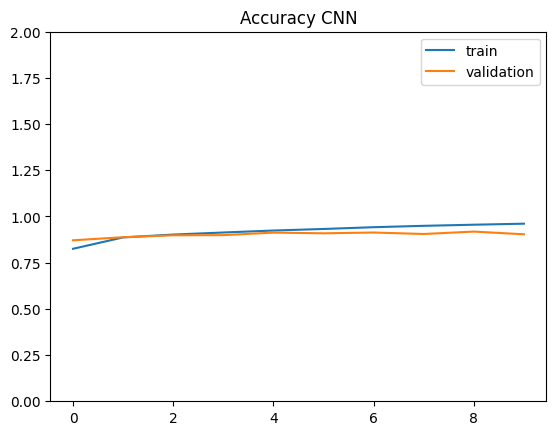

In [27]:
plt.plot(history_cnn_Exp.history['accuracy'], label='train')
plt.plot(history_cnn_Exp.history['val_accuracy'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Accuracy CNN');

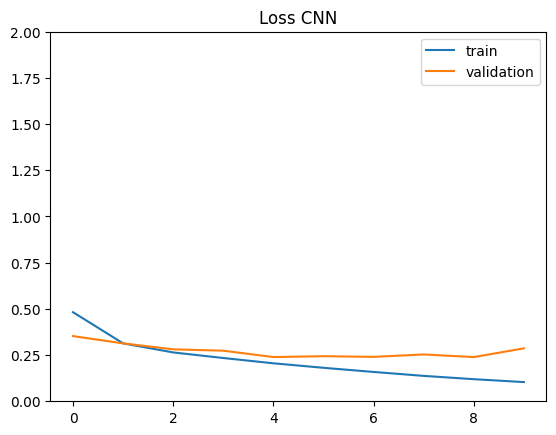

In [28]:
plt.plot(history_cnn_Exp.history['loss'], label='train')
plt.plot(history_cnn_Exp.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss CNN');

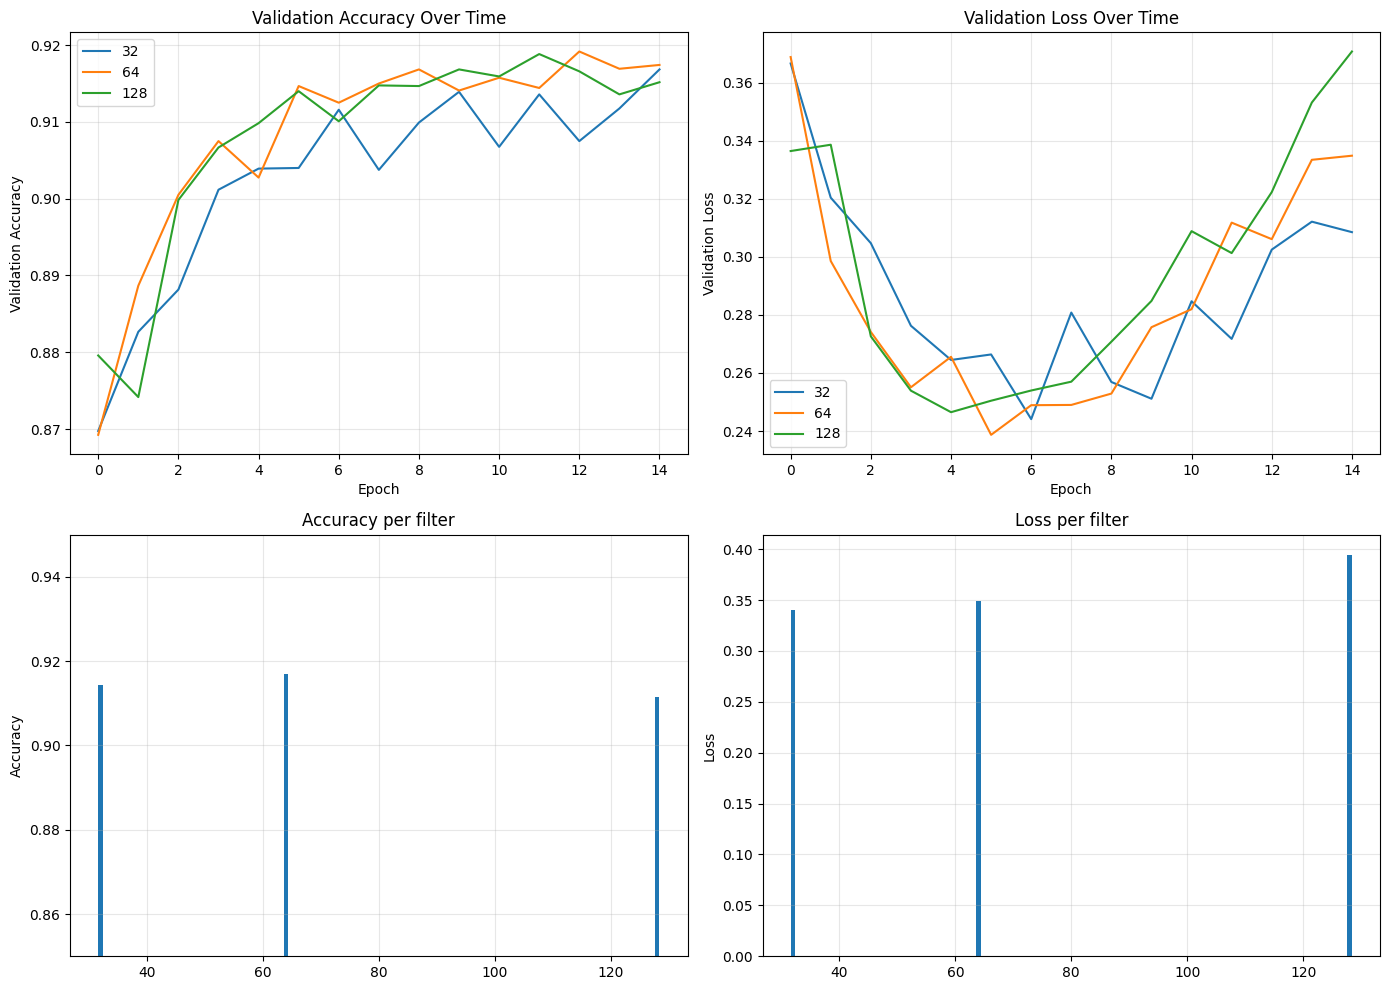


Best Configuration: 64 with 0.9169 accuracy


In [66]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
configs = list(Exp_History.keys())
# Plot training curves - accuracy
for i in No_of_filters:
    axes[0, 0].plot(Exp_History[i]['history']['val_accuracy'], label=i)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Validation Accuracy')
    axes[0, 0].set_title('Validation Accuracy Over Time')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# Plot training curves - loss
for i in No_of_filters:
    axes[0, 1].plot(Exp_History[i]['history']['val_loss'], label=i)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Validation Loss')
    axes[0, 1].set_title('Validation Loss Over Time')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)


# Plot test accuracies

accuracy_test = [Exp_History[i]['Accuracy'] for i in No_of_filters]
axes[1, 0].bar(No_of_filters, accuracy_test)
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy per filter')
axes[1, 0].set_ylim([0.85, 0.95])
axes[1, 0].grid(True, alpha=0.3)

# Plot test losses
loss_test = [Exp_History[i]['Loss'] for i in No_of_filters]
axes[1, 1].bar(No_of_filters, loss_test)
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Loss per filter')
axes[1, 1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Find best configuration
best_config = max(Exp_History.items(), key=lambda x: x[1]['Accuracy'])
print(f"\nBest Configuration: {best_config[0]} with {best_config[1]['Accuracy']:.4f} accuracy")

In [67]:
Exp_History

{32: {'Accuracy': 0.9143000245094299,
  'Loss': 0.3397431969642639,
  'history': {'accuracy': [0.817187488079071,
    0.8783125281333923,
    0.893750011920929,
    0.9070416688919067,
    0.9148958325386047,
    0.9224166870117188,
    0.9300833344459534,
    0.937416672706604,
    0.9439374804496765,
    0.9494166374206543,
    0.9553333520889282,
    0.9596458077430725,
    0.9645624756813049,
    0.9688125252723694,
    0.9729166626930237],
   'loss': [0.5129495859146118,
    0.33632200956344604,
    0.2889552116394043,
    0.2541254162788391,
    0.22929638624191284,
    0.20775416493415833,
    0.1880967766046524,
    0.171181783080101,
    0.15213167667388916,
    0.13737358152866364,
    0.12067048996686935,
    0.10917489975690842,
    0.09729986637830734,
    0.08428595215082169,
    0.07545316219329834],
   'val_accuracy': [0.8697500228881836,
    0.8826666474342346,
    0.8881666660308838,
    0.9011666774749756,
    0.9039166569709778,
    0.9039999842643738,
    0.9115833

In [6]:
# B. Test presence or absence of regularization
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from keras.layers import Conv2D
from keras.layers import MaxPooling2D,Flatten,Dense

from keras.layers import Dropout

dropout_values = [0.2, 0.5]
Exp_Drop_History = {}
for i in dropout_values:

    print("Experiment With: ", i, " dropout\n")
    model = Sequential()

    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(i))

    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(i))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(i))

    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


    # Train the model
    history_drop = model.fit(
        X_train, y_train_onehot_enc,
        epochs=15,
        batch_size=64,
        validation_split=0.2
    )


    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test_onehot_enc)
    print(
    f'\nLoss: {loss:4f}',
    f'\nAccuracy: {accuracy*100:4f}%\n\n'
    )

    Exp_Drop_History[i] = {
    'Accuracy': accuracy,
    'Loss': loss,
    'history': history_drop.history
    }



Experiment With:  0.2  dropout

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.6953 - loss: 0.8321 - val_accuracy: 0.8524 - val_loss: 0.4097
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.8501 - loss: 0.4116 - val_accuracy: 0.8832 - val_loss: 0.3297
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.8757 - loss: 0.3395 - val_accuracy: 0.8931 - val_loss: 0.2989
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.8849 - loss: 0.3105 - val_accuracy: 0.8966 - val_loss: 0.2848
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.8944 - loss: 0.2825 - val_accuracy: 0.9037 - val_loss: 0.2623
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9002 - loss: 0.2744 - val_accuracy: 0.9044 - val_loss: 0.2581
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9055 - loss: 0.2514 - val_accuracy: 0.9057 - val_loss: 0.2498
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - ac

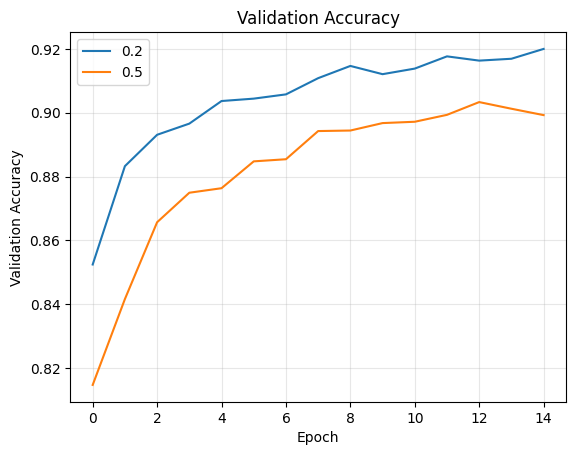

In [9]:
# Plot training and validation accuracy curves
for i in dropout_values:
    plt.plot(Exp_Drop_History[i]['history']['val_accuracy'], label=i)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

In [10]:
# Find best configuration
best_drop_config = max(Exp_Drop_History.items(), key=lambda x: x[1]['Accuracy'])
print(f"\nBest Configuration: {best_drop_config[0]} with {best_drop_config[1]['Accuracy']:.4f} accuracy")


Best Configuration: 0.2 with 0.9195 accuracy


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?
For Dropout:
Experiment With:  0.2  dropout:

Loss: 0.229012 
Accuracy: 91.949999%


Experiment With:  0.5  dropout:

Loss: 0.282485 
Accuracy: 89.789999%

For Dropout, Best Configuration: 0.2 with 0.9195 accuracy

For Filters, Best Configuration: 64 with 0.9169 accuracy

Overall model improved when using 64 filters instead of 32 and 128 with Epoch 15.
Also, model performance improved significantly with using drop out rate of 0.2


# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [5]:
# B. Test presence or absence of regularization
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from keras.layers import Conv2D
from keras.layers import MaxPooling2D,Flatten,Dense

from keras.layers import Dropout

Best_filters = [64]
Best_dropout_values = [0.2]

Exp_History = {}
Exp_Drop_History = {}

model = Sequential()

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Train the model
history_best = model.fit(
    X_train, y_train_onehot_enc,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_onehot_enc)
print(
f'\nLoss: {loss:4f}',
f'\nAccuracy: {accuracy*100:4f}%\n\n'
)

Best_History = {
'Accuracy': accuracy,
'Loss': loss,
'history': history_best.history
}



Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 111s 148ms/step - accuracy: 0.8643 - loss: 0.3768 - val_accuracy: 0.8867 - val_loss: 0.3097
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 109s 146ms/step - accuracy: 0.8797 - loss: 0.3239 - val_accuracy: 0.8915 - val_loss: 0.2917
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 114s 152ms/step - accuracy: 0.8958 - loss: 0.2821 - val_accuracy: 0.8999 - val_loss: 0.2684
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 110s 147ms/step - accuracy: 0.9111 - loss: 0.2394 - val_accuracy: 0.9039 - val_loss: 0.2557
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 147ms/step - accuracy: 0.9161 - loss: 0.2222 - val_accuracy: 0.9093 - val_loss: 0.2439
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 114s 152ms/step - accuracy: 0.9222 - loss: 0.2058 - val_accuracy: 0.9109 - val_loss: 0.2476
Epoch 9/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 146ms/step - accuracy: 0.9259 - loss: 0.1934 - val_accuracy: 0.9116 - val_loss: 0.2434
Epoch 10/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 146s 152ms/step - accuracy: 0.9287 

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model performed significantly well with chosen best hyperparameters: including best accuracy and loss parameters according with the use of best filter confifuration, batch size, using dropout regularization to prevent overfitting and underfitting, and thus increasing model performance.

The final model performance contributed to the following below factors:
1.  32, 64 and 128 are the best filter configurations.
2.  A batch size of 64 is a decent default, balancing computational efficiency and convergence stability. 
3.  A sufficient number of epochs (e.g., 10-50+) to allow convergence, using early stopping to prevent overfitting.
4.  Using dropout regularizatiob of 0.2 
5.  Using Adam optimizer with categorical_crossentropy

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.